<a href="https://colab.research.google.com/github/Erica4397/for_coding_camp1/blob/main/ForCodingCampNotebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import everything

Questions(listed from most to least interested)

How does the max_wind_knots, min_pressure_mb and more differ in a long lasting hurricane vs a shorter one?

Are there more hurricanes/storms(be more specific - what type/category?) happening more frequently than before? Why?

How does the max_wind_knots, min_pressure_mb and more change as a hurricane progresses?

In [48]:
!pip install pandas
import pandas as pd
!pip install matplotlib
import matplotlib.pyplot as plt

Load in the dataset and take a look at it

In [28]:
df = pd.read_csv("hurdat2_atlantic_1851_2025_filtered.csv")
#df.head()
#df['status'].unique()
#df['record_identifier'].unique()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55605 entries, 0 to 55604
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   storm_id           55605 non-null  object 
 1   name               55605 non-null  object 
 2   date               55605 non-null  object 
 3   time               55605 non-null  int64  
 4   record_identifier  1256 non-null   object 
 5   status             55605 non-null  object 
 6   latitude           55605 non-null  float64
 7   longitude          55605 non-null  float64
 8   max_wind_knots     55605 non-null  int64  
 9   min_pressure_mb    24659 non-null  float64
 10  year               55605 non-null  int64  
 11  month              55605 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 5.1+ MB


Drop duplicates

In [4]:
df_nodup = df.drop_duplicates()
df_nodup.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55605 entries, 0 to 55604
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   storm_id           55605 non-null  object 
 1   name               55605 non-null  object 
 2   date               55605 non-null  object 
 3   time               55605 non-null  int64  
 4   record_identifier  1256 non-null   object 
 5   status             55605 non-null  object 
 6   latitude           55605 non-null  float64
 7   longitude          55605 non-null  float64
 8   max_wind_knots     55605 non-null  int64  
 9   min_pressure_mb    24659 non-null  float64
 10  year               55605 non-null  int64  
 11  month              55605 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 5.1+ MB


Deal with null values

In [5]:
df_nodup[df_nodup.isna().any(axis=1)]

,storm_id,name,date,time,record_identifier,status,latitude,longitude,max_wind_knots,min_pressure_mb,year,month
0,AL011851,UNNAMED,1851-06-25,0,NaN,HU,28.0,-94.8,80,NaN,1851,6
1,AL011851,UNNAMED,1851-06-25,600,NaN,HU,28.0,-95.4,80,NaN,1851,6
2,AL011851,UNNAMED,1851-06-25,1200,NaN,HU,28.0,-96.0,80,NaN,1851,6
3,AL011851,UNNAMED,1851-06-25,1800,NaN,HU,28.1,-96.5,80,NaN,1851,6
4,AL011851,UNNAMED,1851-06-25,2100,L,HU,28.2,-96.8,80,NaN,1851,6
...,...,...,...,...,...,...,...,...,...,...,...,...
55600,AL132025,MELISSA,2025-10-31,600,NaN,HU,34.5,-65.5,75,972.0,2025,10
55601,AL132025,MELISSA,2025-10-31,1200,NaN,EX,37.7,-62.1,75,972.0,2025,10
55602,AL132025,MELISSA,2025-10-31,1800,NaN,EX,40.6,-58.9,70,972.0,2025,10
55603,AL132025,MELISSA,2025-11-01,0,NaN,EX,43.7,-56.0,70,971.0,2025,11


Scatter plot of the location of hurricanes

Text(0, 0.5, 'Longitude')

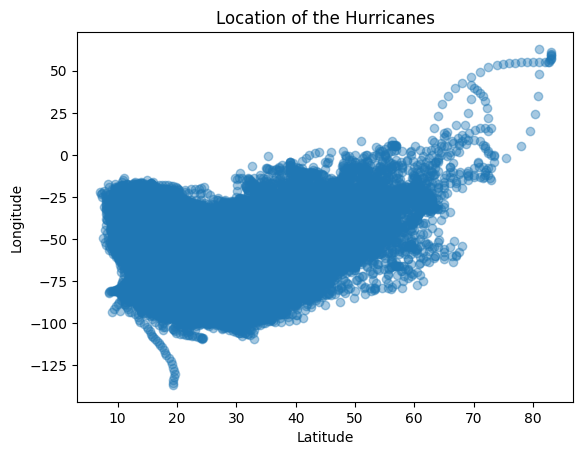

In [6]:
plt.scatter(df_nodup['latitude'], df_nodup['longitude'], alpha = 0.4)
plt.title('Location of the Hurricanes')
plt.xlabel('Latitude')
plt.ylabel('Longitude')

___

<BarContainer object of 7 artists>

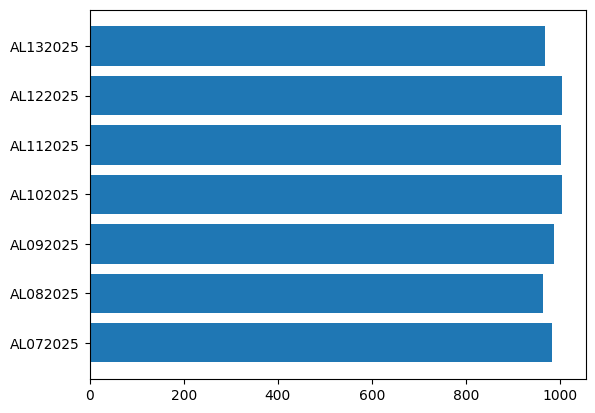

In [33]:
#working on this part
df_last_200r = df.tail(200)
means = df_last_200r.groupby('storm_id')['min_pressure_mb'].mean()
plt.barh(means.index, means.values)

Text(0, 0.5, 'Minimum pressure millibars')

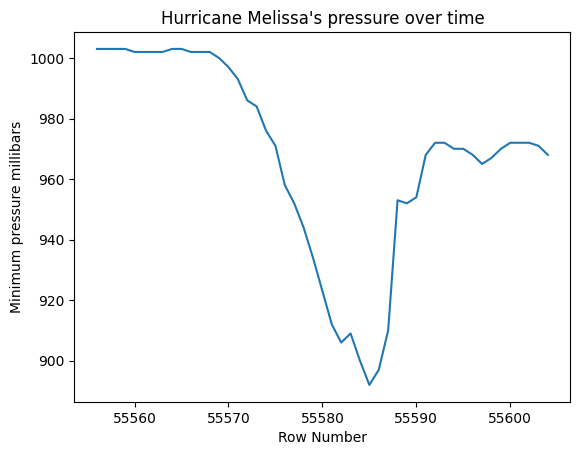

In [52]:
df_melissa = df_nodup.tail(49)
df_melissa

plt.plot(df_melissa.index, df_melissa['min_pressure_mb'])

plt.title("Hurricane Melissa's pressure over time")
plt.xlabel('Row Number')
plt.ylabel('Minimum pressure millibars')